In [1]:
import pandas as pd

df = pd.read_csv('df_labeled_all_final_25.csv')
df.shape

(37569, 20)

In [2]:
import pandas as pd
import numpy as np
import zipfile

zip_path = "preprocessed_data1.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("preprocessed_data1.csv") as f:
        prep_df = pd.read_csv(f)

print(prep_df.shape)

(39119, 12)


In [3]:
prep_df = prep_df[prep_df['id'].isin(df['id'])]

In [4]:
import re

def extract_law_articles(text):
    pattern = r"""
        ст\.\s*          
        (\d+)       
        \s*             
        (?:            
            ч\.?| 
            часть| 
            п\.?|  
            пункт 
        )
        \s*    
        (\d+|[а-яё]) 
    """
    
    matches = re.findall(pattern, text, re.X | re.I)

    result = []
    for article, part in matches:
        if part.isalpha():
            num = ord(part.lower()) - ord('а') + 1
            part = str(num)
        result.append(f"{article}.{part}")
    
    return list(set(result))

In [5]:
df = df.merge(prep_df[['id', 'names']], on='id', how='left')
df.isna().sum()

id                          0
judge                       0
decision                    0
gender_accused              0
prior_convictions           0
alcohol                     0
precrime_argument           0
has_woman_victim            0
has_man_victim              0
method                      0
motive                      0
location                    0
prison_term                 0
many_victims                0
year                        0
season                      0
attempt                     0
victim_child_or_helpless    0
cruel                       0
region_name                 0
names                       0
dtype: int64

In [6]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

df['law_articles'] = df['names'].apply(extract_law_articles)

mlb = MultiLabelBinarizer()
article_matrix = mlb.fit_transform(df['law_articles'])
articles = mlb.classes_

article_df = pd.DataFrame(article_matrix, columns=articles, index=df.index)

df = pd.concat([df, article_df], axis=1)
df.columns = [f'{col}' if col in articles else col for col in df.columns]

In [7]:
for col in df.columns:
    print(col)

id
judge
decision
gender_accused
prior_convictions
alcohol
precrime_argument
has_woman_victim
has_man_victim
method
motive
location
prison_term
many_victims
year
season
attempt
victim_child_or_helpless
cruel
region_name
names
law_articles
105.1
105.2
108.1
109.1
111.1
111.2
111.3
111.4
112.1
112.2
114.1
115.1
115.2
116.1
116.2
117.1
117.2
118.1
119.1
119.2
126.1
126.2
126.3
127.1
127.2
127.3
131.2
132.2
137.1
138.1
139.1
139.2
150.4
157.1
158.1
158.2
158.3
158.4
159.1
159.2
159.3
159.4
160.1
160.2
160.3
160.4
161.1
161.2
161.3
162.1
162.2
162.3
162.4
163.1
163.2
163.3
166.1
166.2
166.3
166.4
167.1
167.2
175.1
175.2
179.2
183.3
187.1
207.1
207.2
208.2
209.1
209.2
209.3
210.1
210.2
212.2
213.1
213.2
214.1
222.1
222.2
222.3
222.4
223.1
223.2
223.3
223.4
226.1
226.3
226.4
228.1
228.2
228.3
230.1
231.1
231.2
232.1
232.2
234.1
234.3
238.1
244.1
244.2
245.1
245.2
256.1
258.1
258.2
260.3
264.1
264.2
268.1
282.2
285.1
285.3
286.1
286.3
291.3
294.2
296.2
296.3
297.1
297.2
30.1
30.3
303.1
306.1
3

In [8]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method',
       ...
       '33.4', '33.5', '330.1', '330.2', '334.2', '335.3', '337.4', '337.5',
       '338.1', '69.5'],
      dtype='object', length=188)

In [9]:
df.isna().sum()

id                   0
judge                0
decision             0
gender_accused       0
prior_convictions    0
                    ..
335.3                0
337.4                0
337.5                0
338.1                0
69.5                 0
Length: 188, dtype: int64

In [10]:
df.isnull().sum()

id                   0
judge                0
decision             0
gender_accused       0
prior_convictions    0
                    ..
335.3                0
337.4                0
337.5                0
338.1                0
69.5                 0
Length: 188, dtype: int64

## Анализ данных для prison_term

In [11]:
import math
import numpy as np

df = df[df['prison_term'] != math.inf]

In [12]:
df['prison_term'].head()
df['prison_term'].describe()

count    37558.000000
mean         9.081634
std         51.721612
min          0.200000
25%          7.000000
50%          8.500000
75%         10.000000
max       9999.000000
Name: prison_term, dtype: float64

In [13]:
# import numpy as np

# df['prison_term'] = np.log(df['prison_term'])

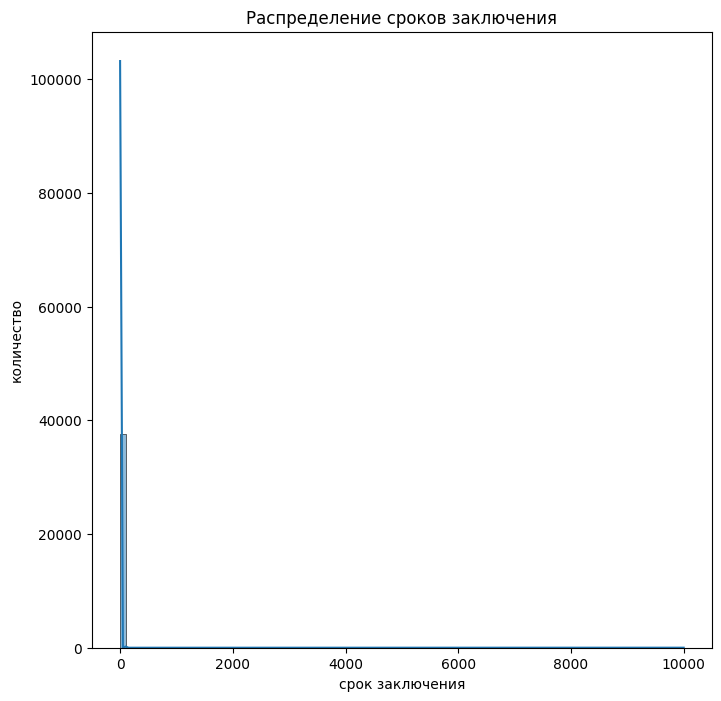

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
plt.title("Распределение сроков заключения")
plt.xlabel("срок заключения")
plt.ylabel("количество")

sns.histplot(data=df["prison_term"], bins=100, kde=True, legend=False)
plt.show()

Есть пик на 9 лет, также возможные выбросы где 100 лет.

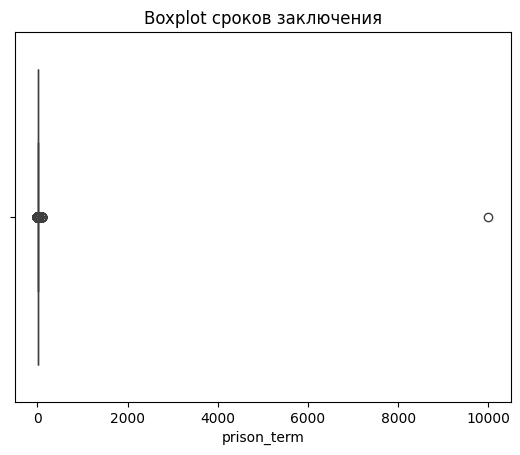

In [15]:
sns.boxplot(x=df['prison_term'])
plt.title('Boxplot сроков заключения')
plt.show()

In [16]:
Q1 = df['prison_term'].quantile(0.35)
Q3 = df['prison_term'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['prison_term'] > lower_bound) & (df['prison_term'] < upper_bound)]
df.shape

(32461, 188)

In [17]:
df['prison_term'] = np.log(df['prison_term'])

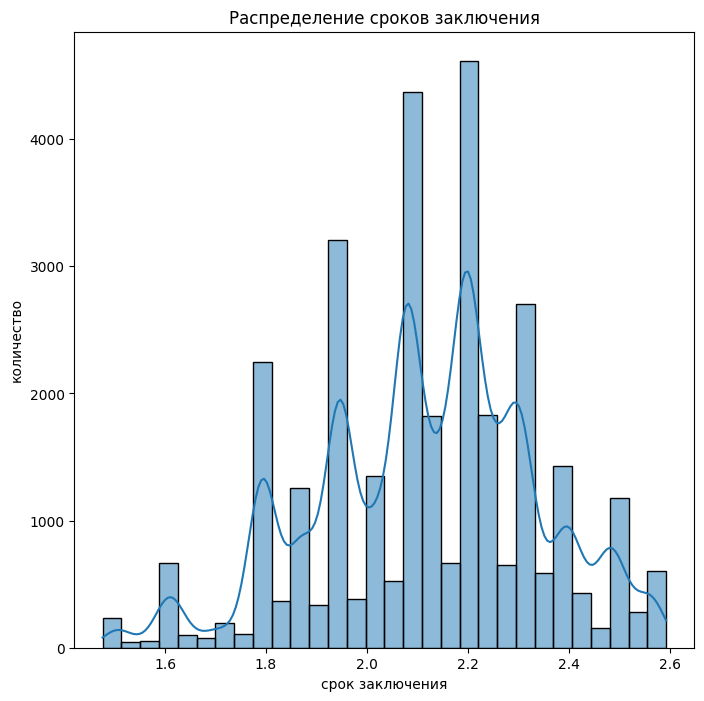

In [18]:
plt.figure(figsize=(8, 8))
plt.title("Распределение сроков заключения")
plt.xlabel("срок заключения")
plt.ylabel("количество")

sns.histplot(data=df["prison_term"], bins=30, kde=True, legend=False)
plt.show()

In [19]:
df['prison_term'].head()
df['prison_term'].describe()

count    32461.000000
mean         2.115846
std          0.219619
min          1.476052
25%          1.945910
50%          2.140066
75%          2.251292
max          2.593384
Name: prison_term, dtype: float64

In [20]:
# fdgvdbhn

In [21]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method',
       ...
       '33.4', '33.5', '330.1', '330.2', '334.2', '335.3', '337.4', '337.5',
       '338.1', '69.5'],
      dtype='object', length=188)

In [22]:
df['gender_accused'].value_counts()

gender_accused
1    27185
0     5276
Name: count, dtype: int64

In [23]:
df['prior_convictions'].value_counts()

prior_convictions
0    27692
1     4769
Name: count, dtype: int64

In [24]:
df['alcohol'].value_counts()

alcohol
1    27828
0     4633
Name: count, dtype: int64

In [25]:
df['precrime_argument'].value_counts()

precrime_argument
1    30260
0     2201
Name: count, dtype: int64

In [26]:
df['has_woman_victim'].value_counts()

has_woman_victim
0    22432
1    10029
Name: count, dtype: int64

In [27]:
df['has_man_victim'] = df['has_man_victim'].astype(int)

In [28]:
df['has_man_victim'].value_counts()

has_man_victim
1    25691
0     6770
Name: count, dtype: int64

In [29]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method',
       ...
       '33.4', '33.5', '330.1', '330.2', '334.2', '335.3', '337.4', '337.5',
       '338.1', '69.5'],
      dtype='object', length=188)

In [30]:
categorical = ['judge', 'decision','season', 'region_name']
numeric = ['year']
multilabel = ['method', 'motive', 'location']
other = ['gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']

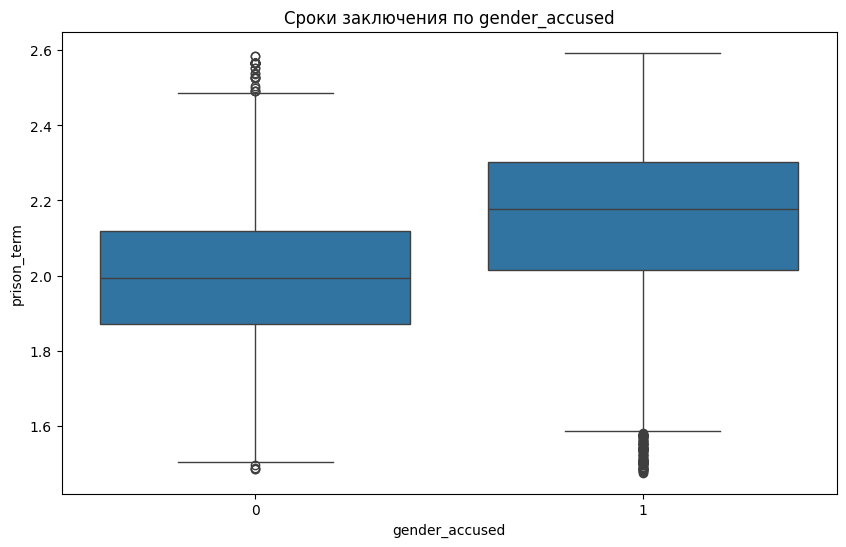

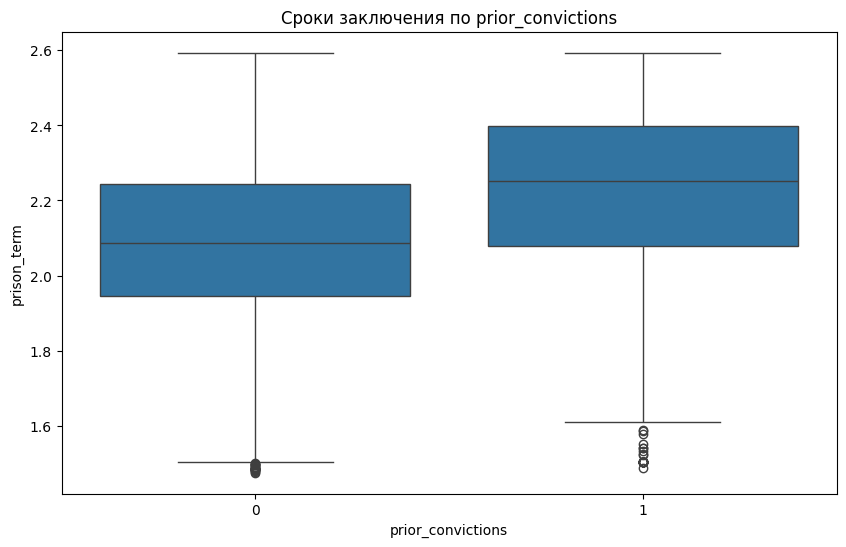

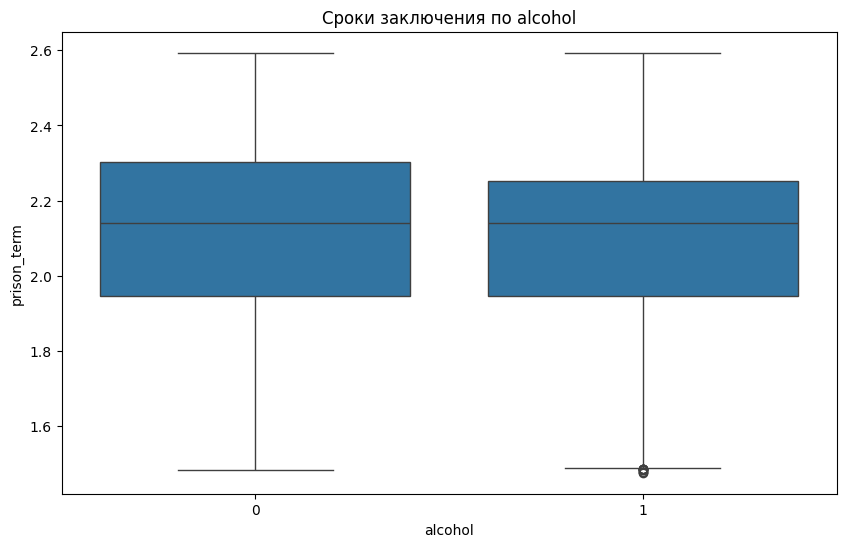

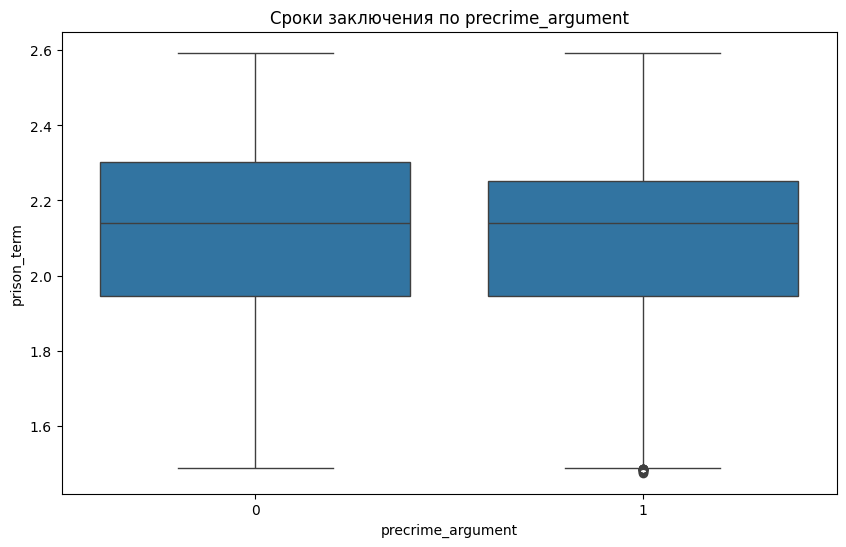

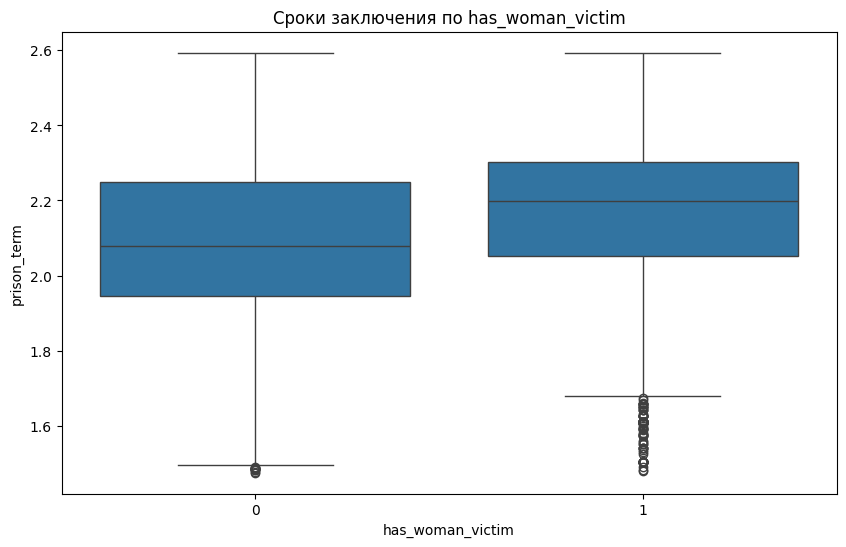

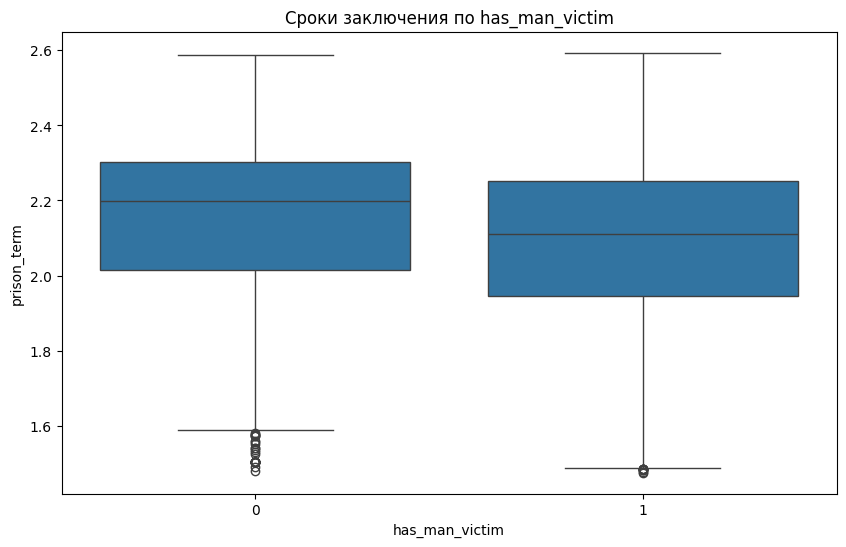

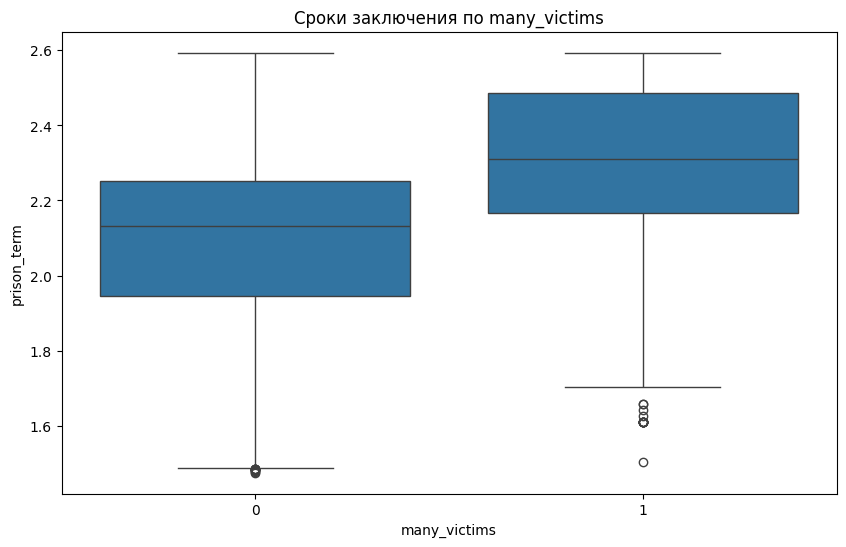

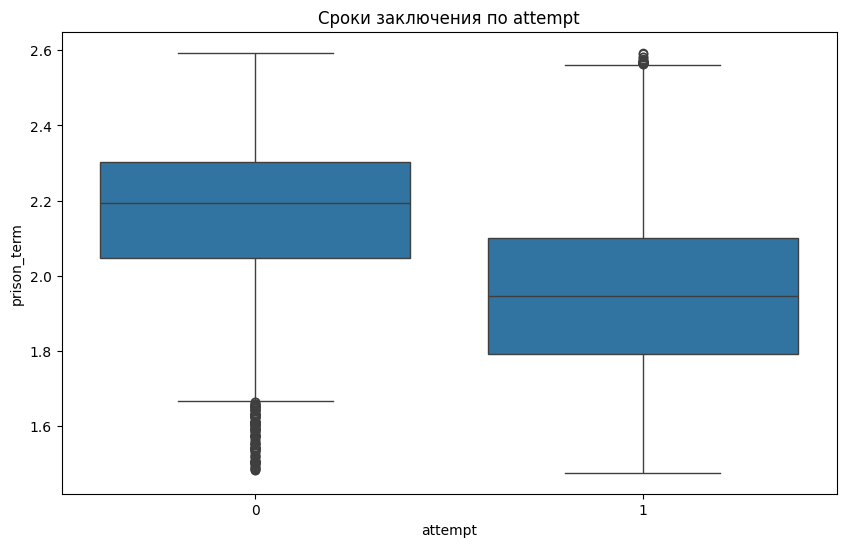

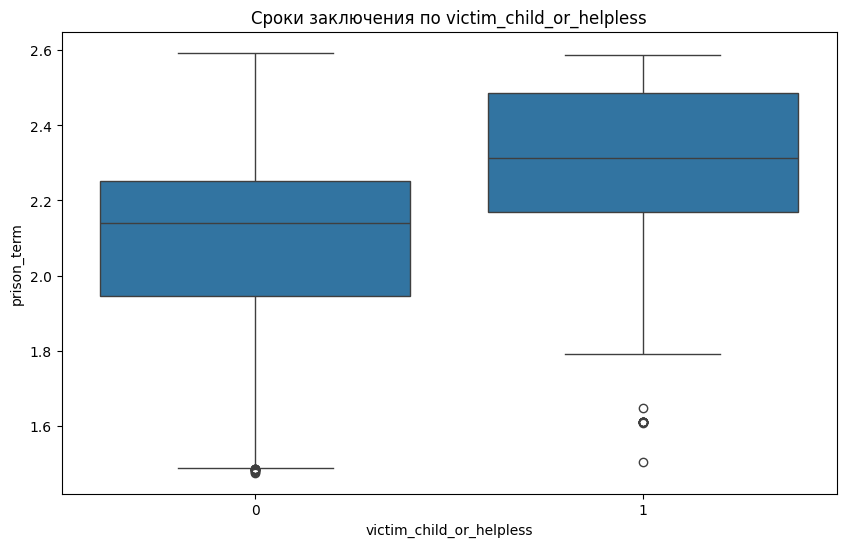

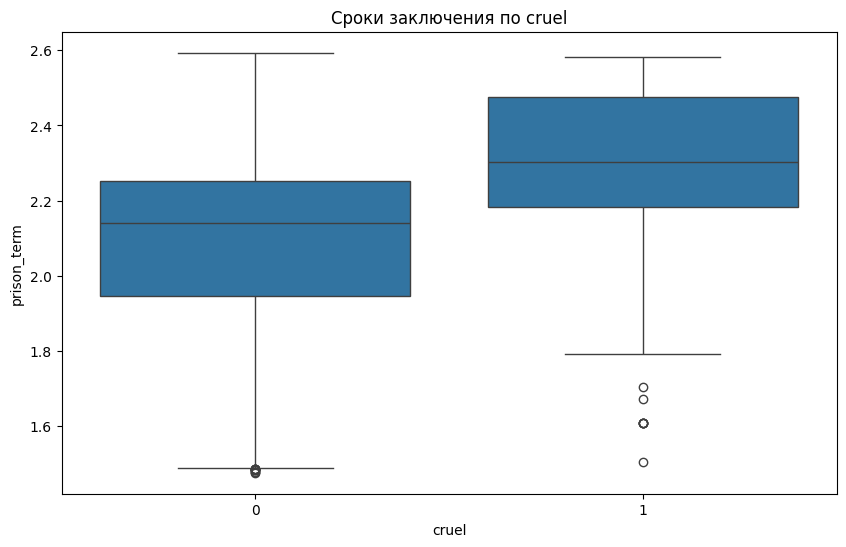

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in other:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='prison_term', data=df)
    plt.title(f"Сроки заключения по {col}")
    plt.show()

In [32]:
def group_top_categories(df, column, top_n=10, other_label='другое'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df

In [33]:
# df = group_top_categories(df, 'judge', top_n=8, other_label='другое судьи')
# df = group_top_categories(df, 'region_name', top_n=8, other_label='другое регионы')

In [34]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# for col in ['season', 'decision', 'judge', 'region_name']:
#     plt.figure(figsize=(20, 6))
#     sns.boxplot(x=col, y='prison_term', data=df)
#     plt.title(f"Сроки заключения по {col}")
#     plt.show()

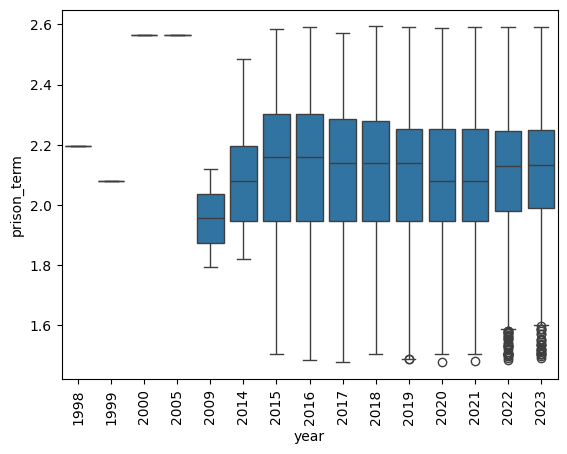

In [35]:
sns.boxplot(x='year', y='prison_term', data=df)
plt.xticks(rotation=90)
plt.show()

In [36]:
multilabel

['method', 'motive', 'location']

In [37]:
df['method'].value_counts()

method
холодное оружие                                                                              16560
физическое воздействие, холодное оружие                                                       7269
физическое воздействие                                                                        1700
огнестрельное оружие                                                                          1398
тяжелые предметы, физическое воздействие                                                      1302
удушение, физическое воздействие                                                              1064
другое                                                                                         862
удушение                                                                                       618
тяжелые предметы                                                                               609
тяжелые предметы, физическое воздействие, холодное оружие                                      320
тяж

In [38]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'прочее',
    'сострадание': 'прочее',
    'страх': 'прочее',
    'жалость': 'прочее',
    'самозащита': 'прочее',
    'защита': 'прочее',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'прочее'

df.loc[:, 'motive'] = df['motive'].apply(map_multiple_motives)
df['motive'].value_counts()

motive
личная неприязнь                        30705
корысть, личная неприязнь                 613
прочее                                    372
личная неприязнь, ревность                319
корысть                                   208
ревность                                  120
личная неприязнь, месть                    66
аморальность, личная неприязнь             15
аморальность                               12
месть                                      10
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, насилие                   4
корысть, месть                              3
личная неприязнь, месть, ревность           3
корысть, личная неприязнь, месть            2
личная неприязнь, прочее                    2
аморальность, месть                         1
корысть, ревность                           1
месть, ревность                             1
Name: count, dtype: int64

In [39]:
df['motive'] = df['motive'].replace('другое', 'другой мотив')
df['motive'] = df['motive'].replace('корысть, другое', 'корысть, другой мотив')
df['motive'] = df['motive'].replace('личная неприязнь, другое', 'личная неприязнь, другой мотив')
df['motive'].value_counts()

motive
личная неприязнь                        30705
корысть, личная неприязнь                 613
прочее                                    372
личная неприязнь, ревность                319
корысть                                   208
ревность                                  120
личная неприязнь, месть                    66
аморальность, личная неприязнь             15
аморальность                               12
месть                                      10
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, насилие                   4
корысть, месть                              3
личная неприязнь, месть, ревность           3
корысть, личная неприязнь, месть            2
личная неприязнь, прочее                    2
аморальность, месть                         1
корысть, ревность                           1
месть, ревность                             1
Name: count, dtype: int64

In [40]:
df['location'].value_counts()

location
жилое помещение                                                                                                                        24468
уличное пространство                                                                                                                    3607
жилое помещение, уличное пространство                                                                                                   1348
другое                                                                                                                                   994
жилое помещение, подъезд и прилегающие зоны                                                                                              421
подъезд и прилегающие зоны                                                                                                               331
общественное место                                                                                                                       324
обще

In [41]:
# df['location'] = df['location'].replace('другое', 'другая локация')

In [42]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

result_rows = []

for col in multilabel:
    temp_df = df.copy()
    temp_df[col] = temp_df[col].str.split(", ")

    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(temp_df[col])
    col_df = pd.DataFrame(col_binarized, columns=mlb.classes_, index=temp_df.index)

    temp_df = pd.concat([temp_df, col_df], axis=1)

    for class_name in mlb.classes_:
        mean_term = temp_df.loc[temp_df[class_name] == 1, 'prison_term'].mean()
        count = temp_df[class_name].sum()

        result_rows.append({
            'Column': col,
            'Class': class_name,
            'Mean Prison Term': round(mean_term, 2) if pd.notna(mean_term) else None,
            'Count': count
        })

result_df = pd.DataFrame(result_rows)
result_df = result_df.sort_values(by='Mean Prison Term', ascending=False).reset_index(drop=True)

print("\nСредние сроки по классам:")
print(result_df.to_string(index=False))



Средние сроки по классам:
  Column                      Class  Mean Prison Term  Count
  motive                    корысть              2.26    827
location               рабочая зона              2.17    282
  method       огнестрельное оружие              2.16   1663
  method                   удушение              2.16   1898
  method     физическое воздействие              2.16  11998
  motive               аморальность              2.16     28
  method           тяжелые предметы              2.15   2496
location       уличное пространство              2.14   5561
location                     другое              2.13   1006
  method                     другое              2.13    946
  motive                    насилие              2.12      4
location         общественное место              2.12    815
  motive           личная неприязнь              2.11  31733
  motive                     прочее              2.11    374
location            жилое помещение              2.11  265

In [43]:
from sklearn.preprocessing import MultiLabelBinarizer

for col in multilabel:
    df[col] = df[col].str.split(", ")
    
    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(df[col])

    col_df = pd.DataFrame(col_binarized, columns=[f"{col}_{cls}" for cls in mlb.classes_], index=df.index)

    df = pd.concat([df, col_df], axis=1)
    df = df.drop(columns=[col])

In [44]:
df

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,prison_term,...,motive_насилие,motive_прочее,motive_ревность,location_другое,location_жилое помещение,location_общественное место,location_общественный транспорт,location_подъезд и прилегающие зоны,location_рабочая зона,location_уличное пространство
0,92093,Толстых Артём Александрович,Вынесен ПРИГОВОР,1,0,0,1,0,1,2.197225,...,0,0,0,0,0,0,0,0,1,1
1,25775,Сон А.И.,Вынесен ПРИГОВОР,1,0,0,0,0,1,2.077797,...,0,0,0,0,0,1,0,0,0,1
2,75488,Акимова Юна Юрьевна,Вынесен ПРИГОВОР,1,0,0,1,1,1,2.564949,...,0,0,0,0,1,0,0,0,0,0
3,126184,Цыренов Тимур Будажапович,Вынесен ПРИГОВОР,0,0,1,1,0,1,2.564949,...,0,0,0,0,0,0,0,0,0,1
4,102316,Ляховецкий Олег Павлович,Вынесен ПРИГОВОР,1,0,0,1,1,0,2.117623,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37561,133487,Комаров Григорий Сергеевич,Вынесен ПРИГОВОР,1,1,1,1,1,0,2.197225,...,0,0,0,0,0,0,0,0,0,1
37562,107387,Хребтов М.В.,Вынесен ПРИГОВОР,1,0,1,1,0,1,2.397895,...,0,0,0,0,1,0,0,0,0,0
37564,6580,Кривцанова Галина Петровна,Вынесен ПРИГОВОР,1,0,1,1,0,1,2.197225,...,0,0,0,0,1,0,0,0,0,0
37565,62712,Егоров Андрей Владимирович,Вынесен ПРИГОВОР,1,0,1,1,1,0,2.197225,...,0,0,1,0,1,0,0,0,0,0


In [45]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term',
       ...
       'motive_насилие', 'motive_прочее', 'motive_ревность', 'location_другое',
       'location_жилое помещение', 'location_общественное место',
       'location_общественный транспорт',
       'location_подъезд и прилегающие зоны', 'location_рабочая зона',
       'location_уличное пространство'],
      dtype='object', length=206)

In [46]:
# df1 = pd.read_csv('df_labeled_all_1.csv')
# df = df[~df['id'].isin(df1['id'])]
# df.shape

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna

target_col = 'prison_term'

categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']
other_features = [
    'gender_accused', 'prior_convictions',
    'has_woman_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',
    
    'method_другое',
    'method_огнестрельное оружие', 'method_тяжелые предметы',
    'method_удушение', 'method_физическое воздействие',
    'method_холодное оружие',
    
    'motive_алкоголь/наркотики',
    'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
    'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
    
    'location_другое', 'location_жилое помещение',
    'location_общественное место', 'location_общественный транспорт',
    'location_подъезд и прилегающие зоны', 'location_рабочая зона',
    'location_уличное пространство'
] + articles.tolist()

selected_features = categorical_features + other_features

X = df[selected_features]
y = df[target_col]

In [48]:
X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.7, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

In [49]:
X_train.shape, X_val.shape, X_test.shape    

((22723, 199), (4869, 199), (4869, 199))

In [50]:
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

In [51]:
df[target_col].describe()

count    32461.000000
mean         2.115846
std          0.219619
min          1.476052
25%          1.945910
50%          2.140066
75%          2.251292
max          2.593384
Name: prison_term, dtype: float64

In [52]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term',
       ...
       'motive_насилие', 'motive_прочее', 'motive_ревность', 'location_другое',
       'location_жилое помещение', 'location_общественное место',
       'location_общественный транспорт',
       'location_подъезд и прилегающие зоны', 'location_рабочая зона',
       'location_уличное пространство'],
      dtype='object', length=206)

In [ ]:
from optuna.importance import get_param_importances

def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 20, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        return r2_score(y_val, val_pred)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    best_params = study.best_params
    print("Best RF Params")
    print(best_params)

    importance = get_param_importances(study)
    print("\nHyperparameter Importance for Random Forest")
    for k, v in importance.items():
        print(f"{k}: {v:.4f}")

    final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.hstack([y_train, y_val])
    )
    test_pred = final_model.predict(X_test)

    print("\nRandom Forest Results")
    print('MAE:', mean_absolute_error(y_test, test_pred))
    print('MSE:', mean_squared_error(y_test, test_pred))
    print('R2:', r2_score(y_test, test_pred))

    importances = final_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': feature_names_rf,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

rf_model, rf_importance = train_random_forest(X_rf_train, y_train, X_rf_val, y_val, X_rf_test, y_test)
print("\nRandom Forest Top 10")
print(rf_importance.head(10))

[I 2025-04-29 19:21:30,132] A new study created in memory with name: no-name-def44bf1-e4d1-49c5-b14c-8456246ea95b


[I 2025-04-29 19:23:15,793] Trial 0 finished with value: 0.2091238745267372 and parameters: {'n_estimators': 376, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.2091238745267372.


In [ ]:
def train_catboost(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide'])
        }
        model = CatBoostRegressor(
            **params,
            cat_features=categorical_features,
            verbose=0
        )
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50
        )
        val_pred = model.predict(X_val)
        return r2_score(y_val, val_pred)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    best_params = study.best_params
    print("\nBest CatBoost Params")
    print(best_params)

    # importance = get_param_importances(study)
    # print("\nHyperparameter Importance for CatBoost")
    # for k, v in importance.items():
    #     print(f"{k}: {v:.4f}")

    final_model = CatBoostRegressor(
        **best_params,
        cat_features=categorical_features,
        verbose=100
    )
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
        early_stopping_rounds=50
    )
    test_pred = final_model.predict(X_test)

    print("\nCatBoost Results")
    print('MAE:', mean_absolute_error(y_test, test_pred))
    print('MSE:', mean_squared_error(y_test, test_pred))
    print('R2:', r2_score(y_test, test_pred))

    feature_importance = pd.DataFrame({
        'Feature': X_train.columns.tolist(),
        'Importance': final_model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

cat_model, cat_importance = train_catboost(X_cb_train, y_train, X_cb_val, y_val, X_cb_test, y_test)

print("\nCatBoost Top 10")
print(cat_importance.head(10))

[I 2025-04-29 11:32:32,254] A new study created in memory with name: no-name-589a04c4-f6db-4125-849b-8020c551d861
[I 2025-04-29 11:32:42,623] Trial 0 finished with value: 0.3567737838782472 and parameters: {'iterations': 1095, 'learning_rate': 0.12893287363819902, 'depth': 4, 'l2_leaf_reg': 0.029481259644252734, 'random_strength': 7.66778939034391, 'bagging_temperature': 0.05663529473446538, 'grow_policy': 'SymmetricTree'}. Best is trial 0 with value: 0.3567737838782472.
[I 2025-04-29 11:32:50,210] Trial 1 finished with value: 0.3569983690161066 and parameters: {'iterations': 1093, 'learning_rate': 0.13070132837485415, 'depth': 5, 'l2_leaf_reg': 0.0018193102592064722, 'random_strength': 1.557322464334102, 'bagging_temperature': 0.16311389613925664, 'grow_policy': 'Depthwise'}. Best is trial 1 with value: 0.3569983690161066.
[I 2025-04-29 11:32:56,582] Trial 2 finished with value: 0.35976654049628576 and parameters: {'iterations': 808, 'learning_rate': 0.03931637794342833, 'depth': 7, '


Best CatBoost Params
{'iterations': 1281, 'learning_rate': 0.010474612222782863, 'depth': 9, 'l2_leaf_reg': 0.08431807692434097, 'random_strength': 1.731622615931149, 'bagging_temperature': 0.6718066672990344, 'grow_policy': 'SymmetricTree'}
0:	learn: 0.2193747	total: 13.8ms	remaining: 17.7s
100:	learn: 0.1851590	total: 1.91s	remaining: 22.4s
200:	learn: 0.1785142	total: 3.68s	remaining: 19.8s
300:	learn: 0.1762729	total: 5.43s	remaining: 17.7s
400:	learn: 0.1752365	total: 7.1s	remaining: 15.6s
500:	learn: 0.1745774	total: 8.85s	remaining: 13.8s
600:	learn: 0.1740855	total: 10.6s	remaining: 12s
700:	learn: 0.1737152	total: 12.3s	remaining: 10.2s
800:	learn: 0.1733861	total: 14.5s	remaining: 8.71s
900:	learn: 0.1730849	total: 16.5s	remaining: 6.97s
1000:	learn: 0.1727748	total: 18.7s	remaining: 5.23s
1100:	learn: 0.1723627	total: 20.7s	remaining: 3.39s
1200:	learn: 0.1719099	total: 22.9s	remaining: 1.53s
1280:	learn: 0.1715574	total: 24.6s	remaining: 0us

CatBoost Results
MAE: 0.134867

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna

target_col = 'prison_term'

# categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']
# other_features = [
#     'gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument',
#     'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt',
#     'victim_child_or_helpless', 'cruel',
    
#     'method_другое',
#     'method_огнестрельное оружие', 'method_тяжелые предметы',
#     'method_удушение', 'method_физическое воздействие',
#     'method_холодное оружие',
    
#     'motive_алкоголь/наркотики',
#     'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
#     'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
    
#     'location_другое', 'location_жилое помещение',
#     'location_общественное место', 'location_общественный транспорт',
#     'location_подъезд и прилегающие зоны', 'location_рабочая зона',
#     'location_уличное пространство'
# ]

categorical_features = []
other_features = [
    '30.3', 'attempt', 'gender_accused', '105.2', 'prior_convictions','has_woman_victim',
  'method_физическое воздействие', 'many_victims', '167.2', '158.2' 
] 

selected_features = categorical_features + other_features

X = df[selected_features]
y = df[target_col]

In [ ]:
cat_model, cat_importance = train_catboost(X_cb_train, y_train, X_cb_val, y_val, X_cb_test, y_test)

print("\nCatBoost Top 10")
print(cat_importance.head(10))

[I 2025-04-29 11:38:14,235] A new study created in memory with name: no-name-98a2651d-26c5-4332-9d86-c8d9286ed3df
[I 2025-04-29 11:38:23,410] Trial 0 finished with value: 0.35867737711202285 and parameters: {'iterations': 948, 'learning_rate': 0.14983991388456372, 'depth': 9, 'l2_leaf_reg': 0.0253570666351976, 'random_strength': 7.609361565841473, 'bagging_temperature': 0.3903868052458286, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.35867737711202285.
[I 2025-04-29 11:38:41,742] Trial 1 finished with value: 0.3579891468450891 and parameters: {'iterations': 1447, 'learning_rate': 0.07731793751585914, 'depth': 6, 'l2_leaf_reg': 4.907655629218052, 'random_strength': 6.037852334431263, 'bagging_temperature': 0.5914187649035423, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.35867737711202285.
[I 2025-04-29 11:39:08,513] Trial 2 finished with value: 0.3586372423987294 and parameters: {'iterations': 835, 'learning_rate': 0.011815788243387595, 'depth': 5, 'l2_leaf_r


Best CatBoost Params
{'iterations': 1202, 'learning_rate': 0.014126408034123569, 'depth': 6, 'l2_leaf_reg': 0.033388972685122253, 'random_strength': 8.90057738136259, 'bagging_temperature': 0.27574290716481686, 'grow_policy': 'Depthwise'}
0:	learn: 0.2193389	total: 55ms	remaining: 1m 6s
100:	learn: 0.1873964	total: 6.09s	remaining: 1m 6s
200:	learn: 0.1818134	total: 11.3s	remaining: 56.2s
300:	learn: 0.1796428	total: 16.2s	remaining: 48.4s
400:	learn: 0.1784110	total: 21s	remaining: 41.9s
500:	learn: 0.1776098	total: 25.6s	remaining: 35.9s
600:	learn: 0.1770664	total: 30.1s	remaining: 30.1s
700:	learn: 0.1765677	total: 34.6s	remaining: 24.7s
800:	learn: 0.1760110	total: 39.1s	remaining: 19.6s
900:	learn: 0.1751753	total: 44s	remaining: 14.7s
1000:	learn: 0.1742711	total: 49.5s	remaining: 9.94s
1100:	learn: 0.1736675	total: 54.9s	remaining: 5.03s
1200:	learn: 0.1731741	total: 1m	remaining: 50.1ms
1201:	learn: 0.1731708	total: 1m	remaining: 0us

CatBoost Results
MAE: 0.13496090671522395